# L6b Lab: Overflow Metabolism in *E. coli*

When *E. coli* grows fast on glucose, it secretes acetate even though oxygen is available, burning part of its glucose only halfway. This overflow metabolism is the bacterial counterpart of the Warburg effect, in which cancer cells secrete lactate. Can flux balance analysis predict when a cell starts to overflow?

In the [L6a lecture](../L6a/CHEME-5800-L6a-Lecture-FluxBalanceAnalysis-Fall-2026.ipynb), we wrote flux balance analysis as a linear program. Here, we apply it to the *E. coli* core model, a 95-reaction network of central metabolism from [BiGG Models](http://bigg.ucsd.edu/models/e_coli_core), and change the cell's oxygen and glucose supply live.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Load and check a metabolic model:__ Build the stoichiometric matrix of the BiGG core model of *Escherichia coli* and read its default bounds. Explain the sign convention of its exchange reactions.
> * __Predict growth with flux balance analysis:__ Maximize the biomass flux and read the uptake and secretion rates that come with it. Check the solution against the balances and the bounds.
> * __Explain overflow metabolism:__ Predict how growth and secretion change when the oxygen or glucose supply changes, and check each prediction against the flow diagram. Explain why a cell short of oxygen secretes acetate, ethanol, or formate.

In this lab, we load the model, predict aerobic growth on glucose, and then limit the oxygen supply live, predicting each result before we solve. The code is complete, and each task ends with questions for discussion.

Let's get started!

___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library, this lab's model and plotting helpers, and the packages used here.

Let's set up our code environment:

In [1]:
# Load packages and paths from this notebook's local setup file -
include(joinpath(@__DIR__, "Include.jl"))

# Choose one theme; after changing it, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark -
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/) for the functions and types used here.

The model is in [data/e_coli_core.json](data/e_coli_core.json), downloaded from BiGG. The lab's functions are complete and live in [src/Compute.jl](src/Compute.jl); they solve the linear program with the flux balance code from L6a, in [code/src/FluxBalance.jl](../../../code/src/FluxBalance.jl).

__Optional exercise:__ After class, rebuild [the `solve_growth(...)` function](src/Compute.jl) from its docstring and rerun the notebook; the reference is in [src/Compute-solution.jl](src/Compute-solution.jl).

___

## Task 1: Load the *E. coli* core model

In this task, we load the model and look at its bounds. [The `load_core_model(...)` function](src/Compute.jl) reads the BiGG file into `model`, which holds the stoichiometric matrix, the reaction and metabolite names, and the flux bounds:

In [2]:
# Read the model and build its stoichiometric matrix -
model = load_core_model(joinpath(CHEME5800_L6B_DATA, "e_coli_core.json"));
(metabolites = length(model.metabolites), reactions = length(model.reactions),
 size_of_S = size(model.S), exchanges = length(model.exchanges), biomass = model.biomass)

(metabolites = 72, reactions = 95, size_of_S = (72, 95), exchanges = 20, biomass = "BIOMASS_Ecoli_core_w_GAM")

The model has 72 metabolites and 95 reactions, 20 of them exchanges. BiGG writes an exchange as $\mathrm{A}\rightarrow\varnothing$, so uptake is a negative flux, the opposite of the urea-cycle file in L6a. Here are the default bounds for the main nutrients, acetate, and the maintenance reaction, in $\mathrm{mmol/gDW/h}$:

In [3]:
# Show the default bounds of a few reactions -
shown = ["EX_glc__D_e", "EX_o2_e", "EX_nh4_e", "EX_pi_e", "EX_ac_e", "ATPM"];
rows = [findfirst(==(id), model.reactions) for id in shown];
pretty_table(DataFrame(reaction = shown, name = model.names[rows], lower = model.lower[rows], upper = model.upper[rows]);
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Reaction", "Name", "Lower bound", "Upper bound"],
    alignment = [:l, :l, :r, :r],
)

 ------------- ----------------------------- ------------- -------------
  Reaction      Name                          Lower bound   Upper bound 
 ------------- ----------------------------- ------------- -------------
  EX_glc__D_e   D-Glucose exchange                  -10.0        1000.0
  EX_o2_e       O2 exchange                       -1000.0        1000.0
  EX_nh4_e      Ammonia exchange                  -1000.0        1000.0
  EX_pi_e       Phosphate exchange                -1000.0        1000.0
  EX_ac_e       Acetate exchange                      0.0        1000.0
  ATPM          ATP maintenance requirement          8.39        1000.0
 ------------- ----------------------------- ------------- -------------


Glucose uptake is limited to 10, while oxygen uptake is effectively unlimited at 1000. Acetate can only be secreted. The maintenance reaction `ATPM`, the ATP a cell spends whether it grows or not, must run at 8.39 or more.

### Things to think about

* __Question:__ Why is the lower bound on `EX_glc__D_e` negative while the lower bound on `EX_ac_e` is zero?
* __Question:__ Which bound would you change to model cells in a sealed flask that runs out of oxygen?

___

## Task 2: Predict growth on glucose

In this task, we maximize growth with plenty of oxygen. The objective is the biomass reaction, whose flux is the growth rate in $1/\mathrm{h}$. [The `solve_growth(...)` function](src/Compute.jl) sets its objective coefficient to one and calls [the `solve_flux_balance(...)` function](../../../code/src/FluxBalance.jl) from L6a:

In [4]:
# Maximize the biomass flux -
result = solve_growth(model);
(status = result.status, growth = round(result.growth; digits = 3))

(status = MathOptInterface.OPTIMAL, growth = 0.874)

Before reading the fluxes, we check them independently of the solver with [the `flux_checks(...)` function](src/Compute.jl):

In [5]:
# Check that every metabolite balances and every flux is within its bounds -
checks = flux_checks(model, result);
@testset "Flux balance checks" begin
    @test result.optimal
    @test checks.balance_ok # S v = 0 for every metabolite
    @test checks.bounds_ok # every flux within its bounds
end;
(maximum_residual = checks.maximum_residual,)

Test Summary:       | Pass  

Total  Time
Flux balance checks |    3      3  0.3s


(maximum_residual = 2.0730084315800968e-11,)

__Predict:__ with oxygen to spare, where does the glucose carbon go? [The `plot_exchange_flows(...)` function](src/BoundaryPlots.jl) draws what crosses the cell boundary, with arrow width growing with flux:

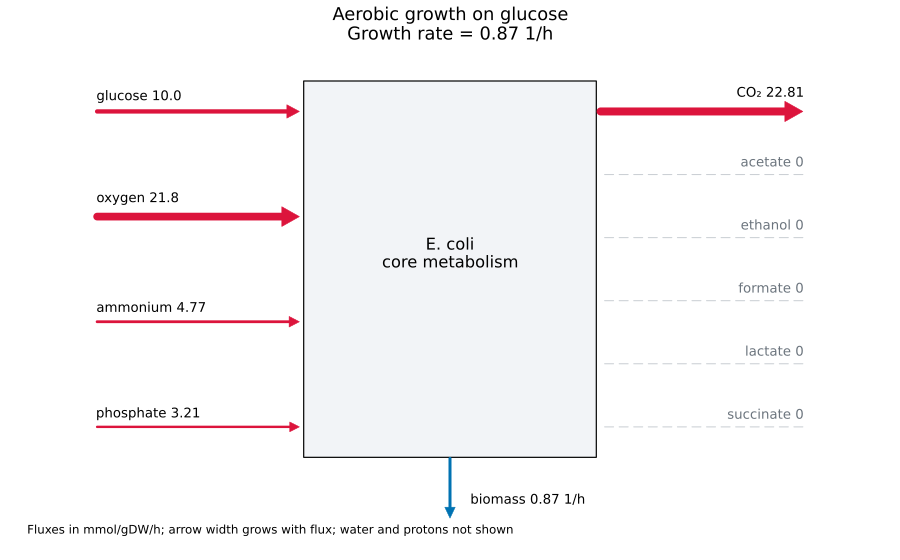

In [6]:
# Draw the uptake and secretion fluxes -
plot_exchange_flows(model, result; title = "Aerobic growth on glucose")

The cell grows at $0.874\;\mathrm{h^{-1}}$ and burns its glucose completely: the carbon leaves as CO₂ or goes into biomass, and no acetate is secreted. It takes up 21.8 of oxygen, far below the limit of 1000, so glucose, not oxygen, limits growth.

### Things to think about

* __Question:__ Acetate secretion is allowed. Why does the best solution secrete none when oxygen is plentiful?
* __Question:__ The cell uses 21.8 of oxygen. What do you predict if we cap oxygen uptake below that?

___

## Task 3: Limit oxygen and predict

In this task, we change the cell's supply live. For each change, predict the growth rate and the secretions before running the cell. [The `with_uptake_limit(...)` function](src/Compute.jl) caps an uptake rate, and [the `with_bounds(...)` function](src/Compute.jl) sets any reaction's bounds; both return a changed copy, so `model` itself never changes.

### Less oxygen

__Predict:__ Oxygen uptake is capped at 15, below the 21.8 the cell used. Does growth drop, and does the cell secrete anything new?

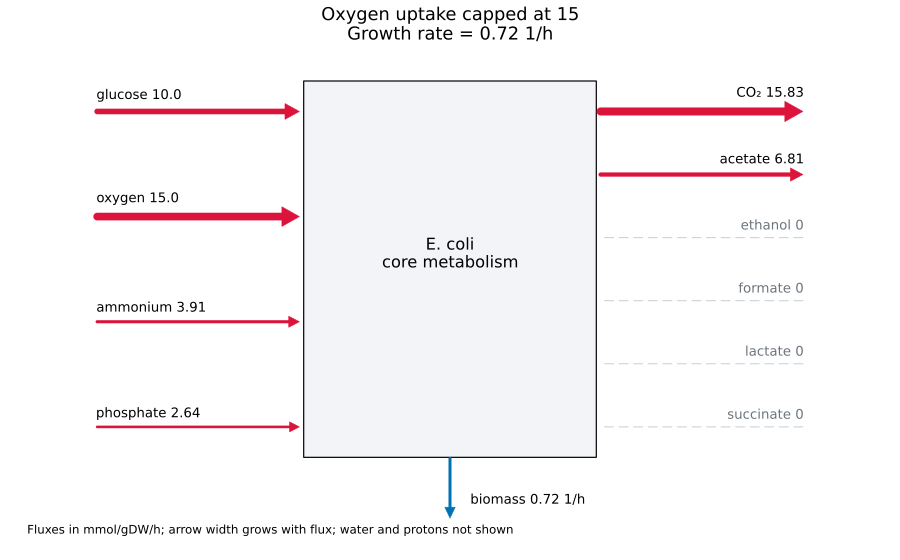

In [7]:
# Describe the change, make it, predict the result, then run -
change = "Oxygen uptake capped at 15"; # the figure title
scenario = with_uptake_limit(model, "EX_o2_e", 15.0);
scenario_result = solve_growth(scenario);
plot_exchange_flows(scenario, scenario_result; title = change)

Growth drops to $0.718\;\mathrm{h^{-1}}$, and the cell secretes 6.8 of acetate. Turning glucose into acetate still yields ATP without oxygen, so the glucose the cell can no longer burn becomes acetate. This is overflow metabolism. Real cells overflow with oxygen present because their capacity to respire is limited; capping oxygen uptake is the simplest way to impose such a limit in the model.

### No oxygen

__Predict:__ Now remove oxygen entirely. Can the cell still grow, and what will it secrete?

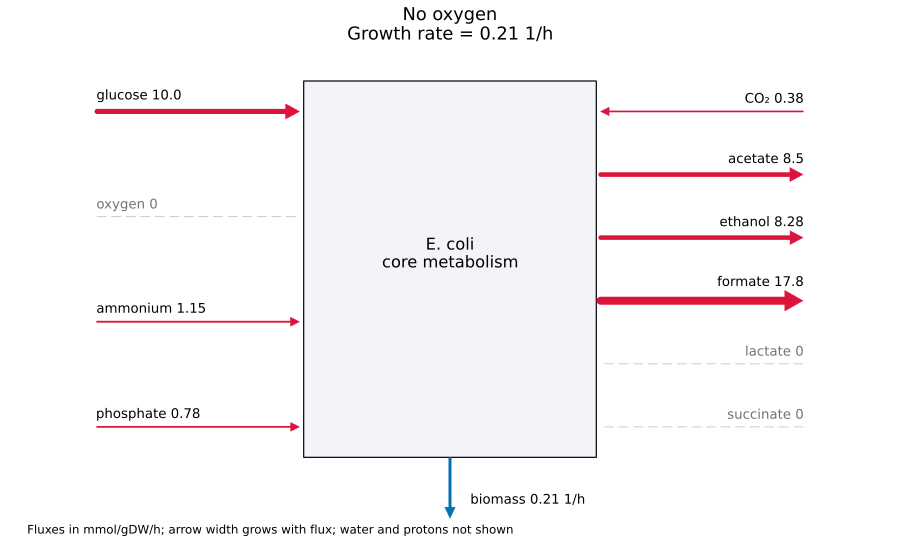

In [8]:
# Describe the change, make it, predict the result, then run -
change = "No oxygen"; # the figure title
scenario = with_uptake_limit(model, "EX_o2_e", 0.0);
scenario_result = solve_growth(scenario);
plot_exchange_flows(scenario, scenario_result; title = change)

The cell still grows, at about a quarter of the aerobic rate. Without oxygen it ferments, secreting acetate, ethanol, and formate, and it even takes up a little CO₂.

### Things to think about

Try each change in the cells above, updating `change` and predicting the result before you run it:

* __Question:__ With oxygen capped at 15, raise glucose uptake to 20: `with_uptake_limit(with_uptake_limit(model, "EX_o2_e", 15.0), "EX_glc__D_e", 20.0)`. How do growth and acetate secretion change? How low must glucose uptake be before no acetate appears?
* __Question:__ With oxygen capped at 15, block acetate secretion: `with_bounds(with_uptake_limit(model, "EX_o2_e", 15.0), "EX_ac_e", 0.0, 0.0)`. What does the cell secrete instead, and what happens to growth?
* __Question:__ Raise the maintenance demand with `with_bounds(model, "ATPM", 20.0, 20.0)`. How does growth change, and does the cell overflow sooner when oxygen is capped?

___

## Summary

In this lab, we used flux balance analysis on the *E. coli* core model to predict growth and to see how the cell's products change when oxygen runs short.

> __Key Takeaways:__
>
> * __A curated model in a few lines:__ We loaded the core model of *Escherichia coli* from BiGG and read its stoichiometric matrix and bounds, including the convention that uptake is a negative exchange flux. The flux balance code from L6a solved it without changes.
>
> * __Growth as the objective:__ We maximized the biomass flux, read the uptake and secretion rates that come with it, and checked the balances and the bounds. With oxygen to spare, the cell burned its glucose completely and secreted no acetate.
>
> * __Oxygen limits and overflow:__ Capping oxygen uptake made the cell secrete acetate, and removing oxygen switched it to fermentation. The model reproduced overflow metabolism because the bounds, not the objective, changed which pathways the best solution could use.

In L6c, we turn to a different use of linear algebra: solving large linear systems by repeated local updates.